# RQ4 (Portfolio Examination)

## From Scratch to Pretrained -- When Does Pretraining Pay Off?
#### *Comparing LSTM, BERT Fine-Tuning, and LLM Prompting Across Dataset Sizes*

**Due Date:** May 26, 2026
**Team:** NW2
**Members:** Nils Wagner, Nick Wenzel

---

### Research Question

> *How do a from-scratch LSTM, a fine-tuned BERT model, and a prompted LLM compare on sentiment classification — and at what dataset size does pretraining become worthwhile?*

### What This Notebook Does

This template provides:
1. IMDB data loading with **configurable subset sizes** (50, 200, 1K, 5K, full)
2. **LSTM classifier** from Week 6 (working out of the box)
3. **BERT fine-tuning** pipeline with HuggingFace Trainer
4. **LLM prompting** pipeline (zero-shot and few-shot)
5. Experiment loop over all (approach × dataset size) combinations
6. Plotting helpers for the key accuracy-vs-size figure

**Your job:** Run the experiments, analyze the results, find the crossover points, and write the report.

The analysis cells at the end compute the report findings from the experiment results.

In [1]:
# ── Setup ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import time

def macro_f1_score(y_true, y_pred, labels=(0, 1)):
    """Compute macro-F1 without an extra sklearn dependency."""
    f1s = []
    for label in labels:
        tp = sum((yt == label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fp = sum((yt != label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fn = sum((yt == label) and (yp != label) for yt, yp in zip(y_true, y_pred))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1s.append(2 * precision * recall / (precision + recall) if (precision + recall) else 0.0)
    return float(np.mean(f1s))

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

def sync_device():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps' and hasattr(torch.mps, 'synchronize'):
        torch.mps.synchronize()

# HuggingFace imports
from datasets import load_dataset
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, pipeline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")

Using device: cuda
Setup complete.


---
## Part 1: Data Loading with Configurable Subset Sizes

The key variable: **how many labeled training examples are available?**
We test with 50, 200, 1,000, 5,000, and the full 25,000.

In [2]:
# ── Load IMDB dataset ──────────────────────────────────────────
dataset = load_dataset("imdb")
print(f"Full dataset: Train {len(dataset['train']):,}, Test {len(dataset['test']):,}")

# ── Function to create balanced subsets ────────────────────────
def get_subset(dataset, n_train, seed=42):
    """Sample n_train examples (balanced) from the training set."""
    if n_train >= len(dataset['train']):
        return dataset['train']
    # Balance: equal positive and negative
    pos = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 1]
    neg = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 0]
    rng = np.random.RandomState(seed)
    pos_sample = rng.choice(pos, n_train // 2, replace=False)
    neg_sample = rng.choice(neg, n_train // 2, replace=False)
    indices = np.concatenate([pos_sample, neg_sample])
    return dataset['train'].select(indices)

# Test it
for n in [50, 200, 1000, 5000]:
    subset = get_subset(dataset, n)
    labels = [ex['label'] for ex in subset]
    print(f"  n={n:5d}: {len(subset)} examples, {sum(labels)} pos, {len(labels)-sum(labels)} neg")

TRAIN_SIZES = [50, 200, 1000, 5000, 25000]
N_SEEDS = 3  # repeat each experiment with 3 different random seeds
print(f"\nExperiment plan: {len(TRAIN_SIZES)} sizes × {N_SEEDS} seeds = {len(TRAIN_SIZES)*N_SEEDS} runs per approach")

Full dataset: Train 25,000, Test 25,000
  n=   50: 50 examples, 25 pos, 25 neg
  n=  200: 200 examples, 100 pos, 100 neg
  n= 1000: 1000 examples, 500 pos, 500 neg
  n= 5000: 5000 examples, 2500 pos, 2500 neg

Experiment plan: 5 sizes × 3 seeds = 15 runs per approach


---
## Part 2: Model 1 — LSTM (From Scratch)

Reuses the LSTM architecture from Week 6 / RQ3. No pretrained embeddings — learns everything from the labeled training data.

In [3]:
# ── Text pipeline for LSTM ─────────────────────────────────────
def tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def build_vocab(texts, max_vocab=20000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in counter.most_common(max_vocab - 2):
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=200):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return ids

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=200):
        self.encodings = [encode(t, vocab, max_len) for t in texts]
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return (torch.tensor(self.encodings[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(self.dropout(h_n.squeeze(0)))

print("LSTM pipeline defined.")

LSTM pipeline defined.


In [4]:
# ── Train and evaluate LSTM ─────────────────────────────────────
def train_lstm(train_subset, test_dataset, vocab, epochs=10, lr=1e-3):
    """Train LSTM on a subset, evaluate on full test set."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]

    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = LSTMClassifier(len(vocab)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    sync_device()
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    sync_device()
    train_time = time.time() - t0

    # Evaluate on full test set
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=128)
    y_true, y_pred = [], []
    sync_device()
    t_eval = time.time()
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            preds = model(bx).argmax(1)
            y_pred.extend(preds.cpu().numpy().tolist())
            y_true.extend(by.cpu().numpy().tolist())
    sync_device()
    inference_time = time.time() - t_eval

    acc = np.mean(np.array(y_pred) == np.array(y_true))
    macro_f1 = macro_f1_score(y_true, y_pred)
    return acc, macro_f1, train_time, inference_time, len(y_true)

# Build vocab from FULL training set (so it's consistent across subset sizes)
all_train_texts = [ex['text'] for ex in dataset['train']]
vocab = build_vocab(all_train_texts)
print(f"Vocabulary: {len(vocab):,} words")

# Prepare full test set (used for all evaluations)
test_texts = [ex['text'] for ex in dataset['test']]
test_labels = [ex['label'] for ex in dataset['test']]
test_ds = SentimentDataset(test_texts, test_labels, vocab)
print(f"Test set: {len(test_ds):,} examples (used for ALL evaluations)")

Vocabulary: 20,000 words
Test set: 25,000 examples (used for ALL evaluations)


---
## Part 2b: Model 2 — LSTM with GloVe Embeddings (Static Pretraining)

Same LSTM architecture, but with pretrained GloVe word vectors instead of random embeddings. This tests: **how much of the LSTM's weakness in RQ3 was due to learning embeddings from scratch?**

In [5]:
# ── Load GloVe embeddings ──────────────────────────────────────
import gensim.downloader as api

print("Loading GloVe embeddings (this may take a moment on first run)...")
try:
    glove = api.load("glove-wiki-gigaword-100")  # 100d GloVe vectors
    GLOVE_DIM = 100
    print(f"Loaded GloVe: {len(glove.key_to_index):,} words, {GLOVE_DIM} dimensions")
except Exception as e:
    print(f"Could not load GloVe via gensim: {e}")
    print("Falling back to random embeddings for the GloVe condition.")
    glove = None
    GLOVE_DIM = 100

Loading GloVe embeddings (this may take a moment on first run)...
Loaded GloVe: 400,000 words, 100 dimensions


In [6]:
# ── Build GloVe embedding matrix for our vocabulary ────────────
def build_glove_matrix(vocab, glove_model, embed_dim=100):
    """Create an embedding matrix from GloVe for our vocabulary."""
    matrix = np.random.randn(len(vocab), embed_dim) * 0.01  # small random for OOV
    found, total = 0, 0
    for word, idx in vocab.items():
        total += 1
        if glove_model is not None and word in glove_model:
            matrix[idx] = glove_model[word]
            found += 1
    print(f"GloVe coverage: {found}/{total} words ({found/total:.1%})")
    return torch.tensor(matrix, dtype=torch.float32)

glove_matrix = build_glove_matrix(vocab, glove)

# ── LSTM with frozen GloVe embeddings ──────────────────────────
def train_lstm_glove(train_subset, test_dataset, vocab, glove_matrix,
                     epochs=10, lr=1e-3):
    """Train LSTM with frozen GloVe embeddings."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]

    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = LSTMClassifier(len(vocab), embed_dim=GLOVE_DIM).to(device)

    # Initialize with GloVe and freeze
    model.embedding.weight.data.copy_(glove_matrix)
    model.embedding.weight.requires_grad = False

    # Only optimize non-embedding parameters
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.CrossEntropyLoss()

    sync_device()
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    sync_device()
    train_time = time.time() - t0

    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=128)
    y_true, y_pred = [], []
    sync_device()
    t_eval = time.time()
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            preds = model(bx).argmax(1)
            y_pred.extend(preds.cpu().numpy().tolist())
            y_true.extend(by.cpu().numpy().tolist())
    sync_device()
    inference_time = time.time() - t_eval

    acc = np.mean(np.array(y_pred) == np.array(y_true))
    macro_f1 = macro_f1_score(y_true, y_pred)
    return acc, macro_f1, train_time, inference_time, len(y_true)

print("LSTM + GloVe pipeline defined.")

GloVe coverage: 19865/20000 words (99.3%)
LSTM + GloVe pipeline defined.


---
## Part 2c: Model 3 — BiLSTM + GloVe + Attention Pooling

Same GloVe embeddings as Model 2, but with a **bidirectional LSTM** and **attention pooling** over all hidden states. This isolates the effect of better architecture and aggregation.

In [7]:
# ── BiLSTM with attention pooling ───────────────────────────────

class AttentionPool(nn.Module):
    """Learned attention pooling over LSTM hidden states."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, lstm_output):
        scores = self.attn(lstm_output).squeeze(-1)  # (B, L)
        weights = F.softmax(scores, dim=1)            # (B, L)
        return (weights.unsqueeze(-1) * lstm_output).sum(dim=1)  # (B, H)

class BiLSTMAttnClassifier(nn.Module):
    """BiLSTM with GloVe embeddings and attention pooling."""
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=2,
                 dropout=0.5, pretrained_embeddings=None, freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        if freeze_emb:
            self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = AttentionPool(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        pooled = self.attention(lstm_out)
        return self.fc(self.dropout(pooled))

def train_bilstm_glove(train_subset, test_dataset, vocab, glove_matrix,
                       epochs=10, lr=1e-3):
    """Train BiLSTM+attention with frozen GloVe embeddings."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]
    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = BiLSTMAttnClassifier(
        len(vocab), embed_dim=GLOVE_DIM,
        pretrained_embeddings=glove_matrix, freeze_emb=True
    ).to(device)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.CrossEntropyLoss()

    sync_device()
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    sync_device()
    train_time = time.time() - t0

    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=128)
    y_true, y_pred = [], []
    sync_device()
    t_eval = time.time()
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            preds = model(bx).argmax(1)
            y_pred.extend(preds.cpu().numpy().tolist())
            y_true.extend(by.cpu().numpy().tolist())
    sync_device()
    inference_time = time.time() - t_eval
    acc = np.mean(np.array(y_pred) == np.array(y_true))
    macro_f1 = macro_f1_score(y_true, y_pred)
    return acc, macro_f1, train_time, inference_time, len(y_true)

print("BiLSTM + GloVe + AttentionPool defined.")
print("  Compared to Model 2: adds bidirectionality + attention pooling")
print("  Compared to Model 1: adds GloVe + bidirectionality + attention pooling")

BiLSTM + GloVe + AttentionPool defined.
  Compared to Model 2: adds bidirectionality + attention pooling
  Compared to Model 1: adds GloVe + bidirectionality + attention pooling


---
## Part 3: Model 4 — BERT Fine-Tuning

Fine-tune DistilBERT (faster than full BERT, 97% of the quality) using HuggingFace.

In [8]:
# ── BERT fine-tuning pipeline ──────────────────────────────────
BERT_MODEL = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    metrics = accuracy_metric.compute(predictions=predictions, references=labels)
    metrics['macro_f1'] = macro_f1_score(labels.tolist(), predictions.tolist())
    return metrics

def train_bert(train_subset, n_train, epochs=3, lr=2e-5):
    """Fine-tune BERT on a subset, evaluate on full test set."""
    # Tokenize train subset
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]

    train_enc = bert_tokenizer(train_texts, truncation=True, padding="max_length",
                                max_length=256, return_tensors="pt")
    train_enc['labels'] = torch.tensor(train_labels)

    # Tokenize test set (first 2000 for speed in template; use full for final results)
    # test_sample = dataset['test'].select(range(min(2000, len(dataset['test']))))
    test_sample = dataset['test']
    test_texts_b = [ex['text'] for ex in test_sample]
    test_labels_b = [ex['label'] for ex in test_sample]
    test_enc = bert_tokenizer(test_texts_b, truncation=True, padding="max_length",
                               max_length=256, return_tensors="pt")
    test_enc['labels'] = torch.tensor(test_labels_b)

    # Create simple datasets
    class SimpleDataset(Dataset):
        def __init__(self, encodings):
            self.encodings = encodings
        def __len__(self): return len(self.encodings['labels'])
        def __getitem__(self, idx):
            return {k: v[idx] for k, v in self.encodings.items()}

    # Fresh model for each run
    model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)

    args = TrainingArguments(
        output_dir=f"./tmp_rq4_{n_train}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=9999,  # suppress logs
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(model=model, args=args,
                      train_dataset=SimpleDataset(train_enc),
                      eval_dataset=SimpleDataset(test_enc),
                      compute_metrics=compute_metrics)

    sync_device()
    t0 = time.time()
    trainer.train()
    sync_device()
    train_time = time.time() - t0

    sync_device()
    t_eval = time.time()
    results = trainer.evaluate()
    sync_device()
    inference_time = time.time() - t_eval
    return results['eval_accuracy'], results['eval_macro_f1'], train_time, inference_time, len(test_sample)

print("BERT fine-tuning pipeline defined.")
print(f"Using: {BERT_MODEL}")

d:\HHN repros\DeepLearning\.venv\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


BERT fine-tuning pipeline defined.
Using: distilbert-base-uncased


---
## Part 4: Model 5 — LLM Prompting

Classify sentiment using prompting — no training, no weight updates. The model classifies based on the prompt alone.

In [9]:
# ── Prompting pipeline ─────────────────────────────────────────
# Use a text-generation model for prompting
# For better results, use a larger model or an API

PROMPT_MODEL = "gpt2"  # Small, runs on CPU. For better results: gpt2-medium, or API

prompt_generator = pipeline("text-generation", model=PROMPT_MODEL,
                            device=device, max_new_tokens=5)

def classify_with_prompt(text, examples=None):
    """Classify sentiment using zero-shot or few-shot prompting."""
    if examples:
        # Few-shot: include examples
        prompt_parts = ["Classify sentiment as Positive or Negative.\n"]
        for ex_text, ex_label in examples:
            label_str = "Positive" if ex_label == 1 else "Negative"
            prompt_parts.append(f'Review: "{ex_text[:100]}" → {label_str}')
        prompt_parts.append(f'Review: "{text[:200]}" →')
        prompt = "\n".join(prompt_parts)
    else:
        # Zero-shot
        prompt = f'Classify the sentiment as Positive or Negative.\nReview: "{text[:200]}"\nSentiment:'

    try:
        result = prompt_generator(prompt, pad_token_id=prompt_generator.tokenizer.eos_token_id)[0]
        generated = result['generated_text'][len(prompt):].strip().lower()
        if 'positive' in generated[:20]:
            return 1
        elif 'negative' in generated[:20]:
            return 0
        else:
            return -1  # couldn't parse
    except Exception:
        return -1

def evaluate_prompting(test_texts, test_labels, examples=None, max_test=200):
    """Evaluate prompting on a sample of the test set."""
    correct, total, unparsed = 0, 0, 0
    y_true, y_pred = [], []
    t0 = time.time()
    for text, label in zip(test_texts[:max_test], test_labels[:max_test]):
        pred = classify_with_prompt(text, examples)
        if pred == -1:
            unparsed += 1
        else:
            y_pred.append(pred)
            y_true.append(label)
            if pred == label:
                correct += 1
        total += 1

    elapsed = time.time() - t0
    valid = total - unparsed
    acc = correct / valid if valid > 0 else 0
    macro_f1 = macro_f1_score(y_true, y_pred) if valid > 0 else 0.0
    return acc, macro_f1, elapsed, total, unparsed

print(f"Prompting pipeline defined. Using: {PROMPT_MODEL}")
print(f"Note: for better prompting results, use gpt2-medium or an API.")

Prompting pipeline defined. Using: gpt2
Note: for better prompting results, use gpt2-medium or an API.


---
## Part 5: Run All Experiments

The core experiment loop: 3 approaches × 5+ dataset sizes × 3 seeds.

**Warning:** This takes a while! BERT fine-tuning is the bottleneck.
On CPU: ~1-2 hours total. On GPU: ~20-30 minutes.

In [10]:
# ── Experiment loop ────────────────────────────────────────────
results = {}

# ── LSTM experiments ──────────────────────────────────────────
print("=" * 60)
print("LSTM EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs, f1s, train_times, inference_times, inference_examples = [], [], [], [], []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, f1, train_t, infer_t, infer_n = train_lstm(subset, test_ds, vocab, epochs=10)
        accs.append(acc)
        f1s.append(f1)
        train_times.append(train_t)
        inference_times.append(infer_t)
        inference_examples.append(infer_n)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, macroF1={f1:.4f}, train={train_t:.1f}s, infer={infer_t:.1f}s")
    results[('LSTM', n_train)] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'macro_f1_mean': np.mean(f1s), 'macro_f1_std': np.std(f1s),
        'train_time_mean': np.mean(train_times), 'train_time_std': np.std(train_times),
        'inference_time_mean': np.mean(inference_times), 'inference_time_std': np.std(inference_times),
        'inference_examples': int(np.mean(inference_examples)),
        'inference_time_per_example_ms': 1000 * np.mean(inference_times) / np.mean(inference_examples),
    }
    print(f"  -> LSTM n={n_train}: acc={np.mean(accs):.4f} +/- {np.std(accs):.4f}, macroF1={np.mean(f1s):.4f}, train={np.mean(train_times):.1f}s, infer={np.mean(inference_times):.1f}s")
    print()

LSTM EXPERIMENTS
  n=   50, seed=0: acc=0.5044, macroF1=0.4764, train=0.2s, infer=0.7s
  n=   50, seed=1: acc=0.5058, macroF1=0.4112, train=0.0s, infer=0.7s
  n=   50, seed=2: acc=0.5095, macroF1=0.4854, train=0.0s, infer=0.7s
  -> LSTM n=50: acc=0.5066 +/- 0.0021, macroF1=0.4577, train=0.1s, infer=0.7s

  n=  200, seed=0: acc=0.5072, macroF1=0.4685, train=0.1s, infer=0.7s
  n=  200, seed=1: acc=0.4977, macroF1=0.4398, train=0.1s, infer=0.7s
  n=  200, seed=2: acc=0.5049, macroF1=0.4741, train=0.1s, infer=0.7s
  -> LSTM n=200: acc=0.5033 +/- 0.0041, macroF1=0.4608, train=0.1s, infer=0.7s

  n= 1000, seed=0: acc=0.5117, macroF1=0.4755, train=0.5s, infer=0.7s
  n= 1000, seed=1: acc=0.4983, macroF1=0.4688, train=0.6s, infer=0.7s
  n= 1000, seed=2: acc=0.5106, macroF1=0.4631, train=0.6s, infer=0.7s
  -> LSTM n=1000: acc=0.5069 +/- 0.0061, macroF1=0.4691, train=0.6s, infer=0.7s

  n= 5000, seed=0: acc=0.6436, macroF1=0.6423, train=2.8s, infer=0.7s
  n= 5000, seed=1: acc=0.5216, macroF1=0.48

In [11]:
# ── LSTM + GloVe experiments ───────────────────────────────────
print("=" * 60)
print("LSTM + GloVe EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs, f1s, train_times, inference_times, inference_examples = [], [], [], [], []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, f1, train_t, infer_t, infer_n = train_lstm_glove(subset, test_ds, vocab, glove_matrix, epochs=10)
        accs.append(acc)
        f1s.append(f1)
        train_times.append(train_t)
        inference_times.append(infer_t)
        inference_examples.append(infer_n)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, macroF1={f1:.4f}, train={train_t:.1f}s, infer={infer_t:.1f}s")
    results[('LSTM+GloVe', n_train)] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'macro_f1_mean': np.mean(f1s), 'macro_f1_std': np.std(f1s),
        'train_time_mean': np.mean(train_times), 'train_time_std': np.std(train_times),
        'inference_time_mean': np.mean(inference_times), 'inference_time_std': np.std(inference_times),
        'inference_examples': int(np.mean(inference_examples)),
        'inference_time_per_example_ms': 1000 * np.mean(inference_times) / np.mean(inference_examples),
    }
    print(f"  -> LSTM+GloVe n={n_train}: acc={np.mean(accs):.4f} +/- {np.std(accs):.4f}, macroF1={np.mean(f1s):.4f}, train={np.mean(train_times):.1f}s, infer={np.mean(inference_times):.1f}s")
    print()

LSTM + GloVe EXPERIMENTS
  n=   50, seed=0: acc=0.5063, macroF1=0.5040, train=0.0s, infer=0.8s
  n=   50, seed=1: acc=0.4939, macroF1=0.4915, train=0.0s, infer=0.7s
  n=   50, seed=2: acc=0.5064, macroF1=0.5043, train=0.0s, infer=0.7s
  -> LSTM+GloVe n=50: acc=0.5022 +/- 0.0059, macroF1=0.5000, train=0.0s, infer=0.7s

  n=  200, seed=0: acc=0.5104, macroF1=0.5060, train=0.1s, infer=0.7s
  n=  200, seed=1: acc=0.5017, macroF1=0.3787, train=0.1s, infer=0.8s
  n=  200, seed=2: acc=0.5172, macroF1=0.4507, train=0.1s, infer=0.9s
  -> LSTM+GloVe n=200: acc=0.5098 +/- 0.0063, macroF1=0.4451, train=0.1s, infer=0.8s

  n= 1000, seed=0: acc=0.5276, macroF1=0.4657, train=0.6s, infer=0.7s
  n= 1000, seed=1: acc=0.5122, macroF1=0.4523, train=0.5s, infer=0.7s
  n= 1000, seed=2: acc=0.5193, macroF1=0.4521, train=0.5s, infer=0.7s
  -> LSTM+GloVe n=1000: acc=0.5197 +/- 0.0063, macroF1=0.4567, train=0.5s, infer=0.7s

  n= 5000, seed=0: acc=0.5914, macroF1=0.5232, train=2.5s, infer=0.7s
  n= 5000, seed=1

In [12]:
# ── BiLSTM + GloVe + Attention experiments ─────────────────────
print("=" * 60)
print("BiLSTM + GloVe + ATTENTION EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs, f1s, train_times, inference_times, inference_examples = [], [], [], [], []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, f1, train_t, infer_t, infer_n = train_bilstm_glove(subset, test_ds, vocab, glove_matrix, epochs=10)
        accs.append(acc)
        f1s.append(f1)
        train_times.append(train_t)
        inference_times.append(infer_t)
        inference_examples.append(infer_n)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, macroF1={f1:.4f}, train={train_t:.1f}s, infer={infer_t:.1f}s")
    results[('BiLSTM+Attn', n_train)] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'macro_f1_mean': np.mean(f1s), 'macro_f1_std': np.std(f1s),
        'train_time_mean': np.mean(train_times), 'train_time_std': np.std(train_times),
        'inference_time_mean': np.mean(inference_times), 'inference_time_std': np.std(inference_times),
        'inference_examples': int(np.mean(inference_examples)),
        'inference_time_per_example_ms': 1000 * np.mean(inference_times) / np.mean(inference_examples),
    }
    print(f"  -> BiLSTM+Attn n={n_train}: acc={np.mean(accs):.4f} +/- {np.std(accs):.4f}, macroF1={np.mean(f1s):.4f}, train={np.mean(train_times):.1f}s, infer={np.mean(inference_times):.1f}s")
    print()

BiLSTM + GloVe + ATTENTION EXPERIMENTS
  n=   50, seed=0: acc=0.5826, macroF1=0.5646, train=0.1s, infer=1.1s
  n=   50, seed=1: acc=0.5447, macroF1=0.5239, train=0.1s, infer=1.1s
  n=   50, seed=2: acc=0.5315, macroF1=0.4774, train=0.1s, infer=1.1s
  -> BiLSTM+Attn n=50: acc=0.5529 +/- 0.0216, macroF1=0.5220, train=0.1s, infer=1.1s

  n=  200, seed=0: acc=0.6310, macroF1=0.6262, train=0.2s, infer=1.1s
  n=  200, seed=1: acc=0.5415, macroF1=0.4526, train=0.2s, infer=1.1s
  n=  200, seed=2: acc=0.6280, macroF1=0.6197, train=0.2s, infer=1.1s
  -> BiLSTM+Attn n=200: acc=0.6002 +/- 0.0415, macroF1=0.5662, train=0.2s, infer=1.1s

  n= 1000, seed=0: acc=0.7440, macroF1=0.7395, train=1.0s, infer=1.1s
  n= 1000, seed=1: acc=0.7446, macroF1=0.7412, train=1.0s, infer=1.1s
  n= 1000, seed=2: acc=0.7368, macroF1=0.7356, train=1.0s, infer=1.2s
  -> BiLSTM+Attn n=1000: acc=0.7418 +/- 0.0035, macroF1=0.7388, train=1.0s, infer=1.1s

  n= 5000, seed=0: acc=0.8354, macroF1=0.8349, train=5.2s, infer=1.1s


In [13]:
# ── BERT experiments ───────────────────────────────────────────
print("=" * 60)
print("BERT EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs, f1s, train_times, inference_times, inference_examples = [], [], [], [], []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, f1, train_t, infer_t, infer_n = train_bert(subset, n_train, epochs=3)
        accs.append(acc)
        f1s.append(f1)
        train_times.append(train_t)
        inference_times.append(infer_t)
        inference_examples.append(infer_n)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, macroF1={f1:.4f}, train={train_t:.1f}s, infer={infer_t:.1f}s")
    results[('BERT', n_train)] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'macro_f1_mean': np.mean(f1s), 'macro_f1_std': np.std(f1s),
        'train_time_mean': np.mean(train_times), 'train_time_std': np.std(train_times),
        'inference_time_mean': np.mean(inference_times), 'inference_time_std': np.std(inference_times),
        'inference_examples': int(np.mean(inference_examples)),
        'inference_time_per_example_ms': 1000 * np.mean(inference_times) / np.mean(inference_examples),
    }
    print(f"  -> BERT n={n_train}: acc={np.mean(accs):.4f} +/- {np.std(accs):.4f}, macroF1={np.mean(f1s):.4f}, train={np.mean(train_times):.1f}s, infer={np.mean(inference_times):.1f}s")
    print()

BERT EXPERIMENTS


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/12 [00:00<?, ?it/s]

{'train_runtime': 0.9727, 'train_samples_per_second': 154.21, 'train_steps_per_second': 12.337, 'train_loss': 0.6793289184570312, 'epoch': 3.0}


  0%|          | 0/782 [00:00<?, ?it/s]

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/4689 [00:00<?, ?it/s]

{'train_runtime': 356.8901, 'train_samples_per_second': 210.149, 'train_steps_per_second': 13.138, 'train_loss': 0.1908992637980846, 'epoch': 3.0}


  0%|          | 0/782 [00:00<?, ?it/s]

  n=25000, seed=2: acc=0.9155, macroF1=0.9155, train=357.0s, infer=30.5s
  -> BERT n=25000: acc=0.9155 +/- 0.0000, macroF1=0.9155, train=367.5s, infer=31.5s



In [14]:
# ── Prompting experiments ──────────────────────────────────────
print("=" * 60)
print("PROMPTING EXPERIMENTS")
print("=" * 60)

prompt_test_texts = [ex['text'] for ex in dataset['test']]
prompt_test_labels = [ex['label'] for ex in dataset['test']]

# Zero-shot
acc_zs, f1_zs, t_zs, infer_n_zs, unp = evaluate_prompting(prompt_test_texts, prompt_test_labels, max_test=200)
results[('Prompt-ZS', 0)] = {
    'mean': acc_zs, 'std': 0.0,
    'macro_f1_mean': f1_zs, 'macro_f1_std': 0.0,
    'train_time_mean': 0.0, 'train_time_std': 0.0,
    'eval_time_mean': t_zs, 'eval_time_std': 0.0,
    'inference_time_mean': t_zs, 'inference_time_std': 0.0,
    'inference_examples': infer_n_zs,
    'inference_time_per_example_ms': 1000 * t_zs / infer_n_zs,
}
print(f"  Zero-shot: acc={acc_zs:.4f}, macroF1={f1_zs:.4f}, unparsed={unp}, eval_time={t_zs:.1f}s")

# Few-shot with k examples
for k in [2, 4, 8]:
    accs, f1s, times, inference_examples = [], [], [], []
    for seed in range(N_SEEDS):
        rng = np.random.RandomState(42 + seed)
        # Sample k examples from training set
        pos = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 1]
        neg = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 0]
        ex_idx = list(rng.choice(pos, k//2, replace=False)) + list(rng.choice(neg, k//2, replace=False))
        examples = [(dataset['train'][i]['text'], dataset['train'][i]['label']) for i in ex_idx]

        acc, f1, t, infer_n, _ = evaluate_prompting(prompt_test_texts, prompt_test_labels, examples, max_test=200)
        accs.append(acc)
        f1s.append(f1)
        times.append(t)
        inference_examples.append(infer_n)
        print(f"  Few-shot k={k}, seed={seed}: acc={acc:.4f}, macroF1={f1:.4f}, eval_time={t:.1f}s")

    results[(f'Prompt-{k}shot', k)] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'macro_f1_mean': np.mean(f1s), 'macro_f1_std': np.std(f1s),
        'train_time_mean': 0.0, 'train_time_std': 0.0,
        'eval_time_mean': np.mean(times), 'eval_time_std': np.std(times),
        'inference_time_mean': np.mean(times), 'inference_time_std': np.std(times),
        'inference_examples': int(np.mean(inference_examples)),
        'inference_time_per_example_ms': 1000 * np.mean(times) / np.mean(inference_examples),
    }
    print(f"  -> Prompt k={k}: acc={np.mean(accs):.4f} +/- {np.std(accs):.4f}, macroF1={np.mean(f1s):.4f}, eval_time={np.mean(times):.1f}s")

print("\nAll experiments complete!")

PROMPTING EXPERIMENTS


d:\HHN repros\DeepLearning\.venv\lib\site-packages\transformers\models\gpt2\modeling_gpt2.py:544: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Zero-shot: acc=0.3333, macroF1=0.2500, unparsed=173, eval_time=7.0s
  Few-shot k=2, seed=0: acc=0.2957, macroF1=0.2282, eval_time=6.3s
  Few-shot k=2, seed=1: acc=0.3194, macroF1=0.2421, eval_time=6.7s
  Few-shot k=2, seed=2: acc=0.2809, macroF1=0.2193, eval_time=6.4s
  -> Prompt k=2: acc=0.2987 +/- 0.0158, macroF1=0.2299, eval_time=6.5s
  Few-shot k=4, seed=0: acc=0.2708, macroF1=0.2131, eval_time=6.9s
  Few-shot k=4, seed=1: acc=0.3557, macroF1=0.2624, eval_time=6.7s
  Few-shot k=4, seed=2: acc=0.3929, macroF1=0.2821, eval_time=6.9s
  -> Prompt k=4: acc=0.3398 +/- 0.0511, macroF1=0.2525, eval_time=6.8s
  Few-shot k=8, seed=0: acc=0.4462, macroF1=0.3085, eval_time=8.1s
  Few-shot k=8, seed=1: acc=0.3692, macroF1=0.2697, eval_time=8.1s
  Few-shot k=8, seed=2: acc=0.4569, macroF1=0.3136, eval_time=8.0s
  -> Prompt k=8: acc=0.4241 +/- 0.0390, macroF1=0.2973, eval_time=8.1s

All experiments complete!


---
## Part 6: The Key Plot — Accuracy vs. Dataset Size

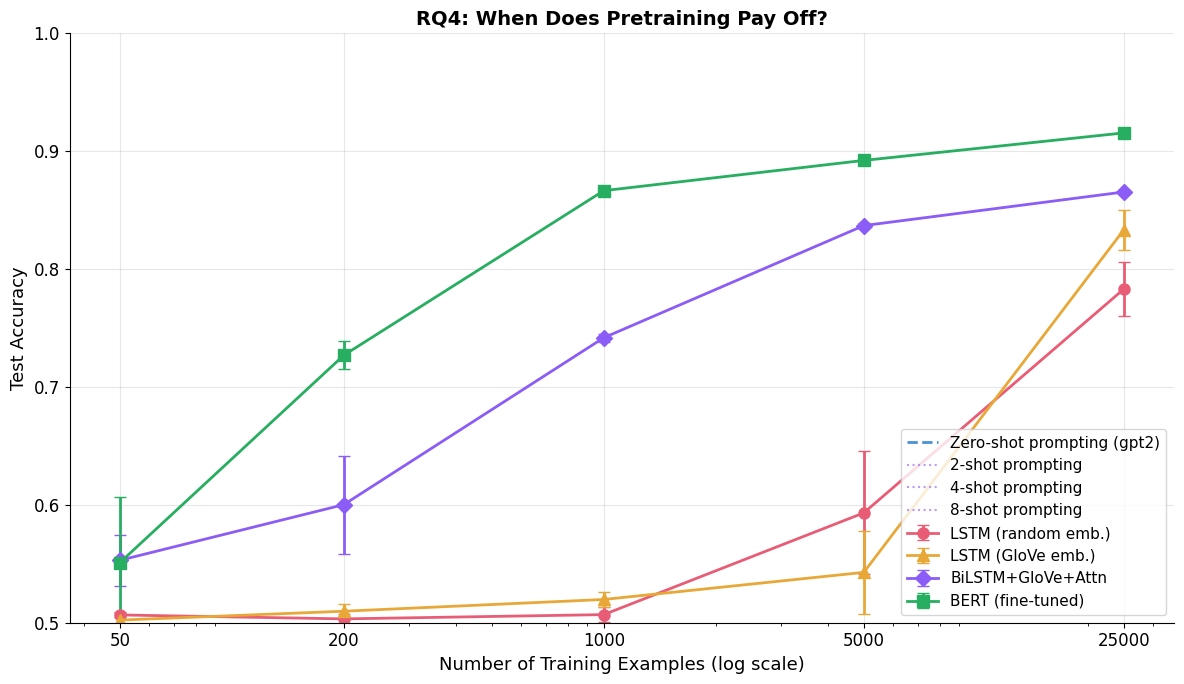

Crossover analysis
GloVe gaps by N: {50: -0.0044, 200: 0.0065, 1000: 0.0128, 5000: -0.0505, 25000: 0.0503}
Architecture/pooling gaps by N: {50: 0.0507, 200: 0.0904, 1000: 0.2221, 5000: 0.2942, 25000: 0.0321}
Contextual pretraining gaps by N: {50: -0.002, 200: 0.1267, 1000: 0.1247, 5000: 0.0553, 25000: 0.0501}
BERT first beats all trained non-BERT models at N = 200
Best few-shot prompting accuracy = 0.4241
BERT first beats best few-shot prompting at N = 50


In [15]:
# ── The central figure ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# LSTM (random) curve
lstm_sizes = TRAIN_SIZES
lstm_accs = [results[('LSTM', n)]['mean'] for n in lstm_sizes]
lstm_stds = [results[('LSTM', n)]['std'] for n in lstm_sizes]
ax.errorbar(lstm_sizes, lstm_accs, yerr=lstm_stds, fmt='o-', color='#E85D75',
            linewidth=2, markersize=8, capsize=4, label='LSTM (random emb.)')

# LSTM (GloVe) curve
glove_accs = [results[('LSTM+GloVe', n)]['mean'] for n in lstm_sizes]
glove_stds = [results[('LSTM+GloVe', n)]['std'] for n in lstm_sizes]
ax.errorbar(lstm_sizes, glove_accs, yerr=glove_stds, fmt='^-', color='#E8A838',
            linewidth=2, markersize=8, capsize=4, label='LSTM (GloVe emb.)')

# BiLSTM + GloVe + Attention curve
bi_accs = [results[('BiLSTM+Attn', n)]['mean'] for n in lstm_sizes]
bi_stds = [results[('BiLSTM+Attn', n)]['std'] for n in lstm_sizes]
ax.errorbar(lstm_sizes, bi_accs, yerr=bi_stds, fmt='D-', color='#8B5CF6',
            linewidth=2, markersize=8, capsize=4, label='BiLSTM+GloVe+Attn')

# BERT curve
bert_accs = [results[('BERT', n)]['mean'] for n in lstm_sizes]
bert_stds = [results[('BERT', n)]['std'] for n in lstm_sizes]
ax.errorbar(lstm_sizes, bert_accs, yerr=bert_stds, fmt='s-', color='#27AE60',
            linewidth=2, markersize=8, capsize=4, label='BERT (fine-tuned)')

# Prompting horizontal lines
if ('Prompt-ZS', 0) in results:
    ax.axhline(y=results[('Prompt-ZS', 0)]['mean'], color='#4A90D9',
               linestyle='--', linewidth=2, label=f"Zero-shot prompting ({PROMPT_MODEL})")

for k in [2, 4, 8]:
    key = (f'Prompt-{k}shot', k)
    if key in results:
        ax.axhline(y=results[key]['mean'], color='#8B5CF6',
                   linestyle=':', linewidth=1.5, alpha=0.6,
                   label=f"{k}-shot prompting")

ax.set_xscale('log')
ax.set_xlabel("Number of Training Examples (log scale)", fontsize=13)
ax.set_ylabel("Test Accuracy", fontsize=13)
ax.set_title("RQ4: When Does Pretraining Pay Off?", fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.0)
ax.set_xticks(TRAIN_SIZES)
ax.set_xticklabels([str(n) for n in TRAIN_SIZES])

plt.tight_layout()
plt.show()

# Crossover points for the report
def _result_mean(model, n):
    return results.get((model, n), {}).get('mean', np.nan)

glove_gaps = {n: _result_mean('LSTM+GloVe', n) - _result_mean('LSTM', n) for n in TRAIN_SIZES}
arch_gaps = {n: _result_mean('BiLSTM+Attn', n) - _result_mean('LSTM+GloVe', n) for n in TRAIN_SIZES}
bert_gaps = {n: _result_mean('BERT', n) - _result_mean('BiLSTM+Attn', n) for n in TRAIN_SIZES}

bert_over_lstm = [n for n in TRAIN_SIZES if _result_mean('BERT', n) > max(_result_mean('LSTM', n), _result_mean('LSTM+GloVe', n), _result_mean('BiLSTM+Attn', n))]
fewshot_values = [results[key]['mean'] for key in [('Prompt-2shot', 2), ('Prompt-4shot', 4), ('Prompt-8shot', 8)] if key in results]
best_fewshot = max(fewshot_values) if fewshot_values else np.nan
bert_over_prompt = [n for n in TRAIN_SIZES if not np.isnan(best_fewshot) and _result_mean('BERT', n) > best_fewshot]

print('Crossover analysis')
print('GloVe gaps by N:', {n: round(gap, 4) for n, gap in glove_gaps.items()})
print('Architecture/pooling gaps by N:', {n: round(gap, 4) for n, gap in arch_gaps.items()})
print('Contextual pretraining gaps by N:', {n: round(gap, 4) for n, gap in bert_gaps.items()})
print('BERT first beats all trained non-BERT models at N =', bert_over_lstm[0] if bert_over_lstm else 'not observed')
print('Best few-shot prompting accuracy =', round(best_fewshot, 4) if not np.isnan(best_fewshot) else 'not available')
print('BERT first beats best few-shot prompting at N =', bert_over_prompt[0] if bert_over_prompt else 'not observed')

### Results Table

In [16]:
# ── Print results table ────────────────────────────────────────
print(f"{'Approach':<20} {'N':>6} {'Accuracy':>10} {'Acc Std':>8} {'MacroF1':>10} {'F1 Std':>8} {'Train(s)':>10} {'Infer(s)':>10} {'EvalN':>8} {'Infer/ex(ms)':>13}")
print("-" * 116)

for approach in ['LSTM', 'LSTM+GloVe', 'BiLSTM+Attn', 'BERT']:
    for n in TRAIN_SIZES:
        r = results.get((approach, n))
        if r:
            infer_s = r.get('inference_time_mean', r.get('eval_time_mean', np.nan))
            default_eval_n = min(2000, len(dataset['test'])) if approach == 'BERT' else len(test_ds)
            eval_n = r.get('inference_examples', default_eval_n)
            infer_ms = r.get('inference_time_per_example_ms', 1000 * infer_s / eval_n if eval_n else np.nan)
            print(f"{approach:<20} {n:>6} {r['mean']:>10.4f} {r['std']:>8.4f} {r.get('macro_f1_mean', np.nan):>10.4f} {r.get('macro_f1_std', np.nan):>8.4f} {r.get('train_time_mean', np.nan):>10.1f} {infer_s:>10.1f} {eval_n:>8.0f} {infer_ms:>13.3f}")

for key in [('Prompt-ZS', 0), ('Prompt-2shot', 2), ('Prompt-4shot', 4), ('Prompt-8shot', 8)]:
    r = results.get(key)
    if r:
        infer_s = r.get('inference_time_mean', r.get('eval_time_mean', np.nan))
        eval_n = r.get('inference_examples', 200)
        infer_ms = r.get('inference_time_per_example_ms', 1000 * infer_s / eval_n if eval_n else np.nan)
        print(f"{key[0]:<20} {key[1]:>6} {r['mean']:>10.4f} {r['std']:>8.4f} {r.get('macro_f1_mean', np.nan):>10.4f} {r.get('macro_f1_std', np.nan):>8.4f} {r.get('train_time_mean', np.nan):>10.1f} {infer_s:>10.1f} {eval_n:>8.0f} {infer_ms:>13.3f}")

print("\nUse this table in the Results section of the report.")

Approach                  N   Accuracy  Acc Std    MacroF1   F1 Std   Train(s)   Infer(s)    EvalN  Infer/ex(ms)
--------------------------------------------------------------------------------------------------------------------
LSTM                     50     0.5066   0.0021     0.4577   0.0331        0.1        0.7    25000         0.027
LSTM                    200     0.5033   0.0041     0.4608   0.0150        0.1        0.7    25000         0.027
LSTM                   1000     0.5069   0.0061     0.4691   0.0051        0.6        0.7    25000         0.026
LSTM                   5000     0.5932   0.0520     0.5760   0.0672        2.8        0.7    25000         0.027
LSTM                  25000     0.7831   0.0226     0.7829   0.0225       14.8        0.7    25000         0.027
LSTM+GloVe               50     0.5022   0.0059     0.5000   0.0060        0.0        0.7    25000         0.030
LSTM+GloVe              200     0.5098   0.0063     0.4451   0.0521        0.1        0.8   

---
## Part 7: Error Analysis

Pick one dataset size (e.g., n=200) and compare what each approach gets right and wrong.

The following cell trains an additional n=200 pair of models for qualitative error analysis and prints concrete examples for the report.

In [17]:
# Error analysis on n=200
ERROR_N_TRAIN = 200
ERROR_N_TEST = 120  # keep qualitative analysis manageable; increase if needed

def _balanced_test_sample(n=ERROR_N_TEST, seed=123):
    rng = np.random.RandomState(seed)
    pos = [i for i, ex in enumerate(dataset['test']) if ex['label'] == 1]
    neg = [i for i, ex in enumerate(dataset['test']) if ex['label'] == 0]
    half = n // 2
    idx = list(rng.choice(pos, half, replace=False)) + list(rng.choice(neg, n - half, replace=False))
    rng.shuffle(idx)
    return idx

def _train_lstm_for_error(train_subset):
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]
    train_loader = DataLoader(SentimentDataset(train_texts, train_labels, vocab), batch_size=64, shuffle=True)
    model = LSTMClassifier(len(vocab)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(10):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    return model

def _predict_lstm(model, texts, labels):
    loader = DataLoader(SentimentDataset(texts, labels, vocab), batch_size=128)
    preds = []
    model.eval()
    with torch.no_grad():
        for bx, _ in loader:
            preds.extend(model(bx.to(device)).argmax(1).cpu().numpy().tolist())
    return preds

def _train_predict_bert_for_error(train_subset, texts, labels):
    class SimpleDataset(Dataset):
        def __init__(self, encodings):
            self.encodings = encodings
        def __len__(self):
            return len(self.encodings['labels'])
        def __getitem__(self, idx):
            return {k: v[idx] for k, v in self.encodings.items()}

    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]
    train_enc = bert_tokenizer(train_texts, truncation=True, padding='max_length', max_length=256, return_tensors='pt')
    train_enc['labels'] = torch.tensor(train_labels)
    test_enc = bert_tokenizer(texts, truncation=True, padding='max_length', max_length=256, return_tensors='pt')
    test_enc['labels'] = torch.tensor(labels)

    model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)
    args = TrainingArguments(
        output_dir='./tmp_rq4_error_analysis', num_train_epochs=3,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, weight_decay=0.01, eval_strategy='no',
        save_strategy='no', logging_steps=9999, report_to='none',
        fp16=torch.cuda.is_available()
    )
    trainer = Trainer(model=model, args=args, train_dataset=SimpleDataset(train_enc))
    trainer.train()
    logits = trainer.predict(SimpleDataset(test_enc)).predictions
    return np.argmax(logits, axis=-1).tolist()

def _label_name(label):
    return 'Positive' if label == 1 else 'Negative'

def _snippet(text, max_chars=450):
    return re.sub(r'\s+', ' ', text).strip()[:max_chars] + ('...' if len(text) > max_chars else '')

error_train = get_subset(dataset, ERROR_N_TRAIN, seed=2024)
error_idx = _balanced_test_sample(ERROR_N_TEST, seed=2024)
error_texts = [dataset['test'][i]['text'] for i in error_idx]
error_labels = [dataset['test'][i]['label'] for i in error_idx]

print(f'Training error-analysis models on n={ERROR_N_TRAIN}...')
error_lstm = _train_lstm_for_error(error_train)
lstm_preds = _predict_lstm(error_lstm, error_texts, error_labels)
bert_preds = _train_predict_bert_for_error(error_train, error_texts, error_labels)

rng = np.random.RandomState(2024)
pos = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 1]
neg = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 0]
shot_idx = list(rng.choice(pos, 4, replace=False)) + list(rng.choice(neg, 4, replace=False))
prompt_examples = [(dataset['train'][i]['text'], dataset['train'][i]['label']) for i in shot_idx]
prompt_preds = [classify_with_prompt(text, prompt_examples) for text in error_texts]

categories = {
    'BERT correct, LSTM wrong': [],
    'Prompting correct, both trained models wrong': [],
    'All wrong': []
}

for text, gold, lstm_pred, bert_pred, prompt_pred in zip(error_texts, error_labels, lstm_preds, bert_preds, prompt_preds):
    if bert_pred == gold and lstm_pred != gold:
        categories['BERT correct, LSTM wrong'].append((text, gold, lstm_pred, bert_pred, prompt_pred))
    if prompt_pred == gold and lstm_pred != gold and bert_pred != gold:
        categories['Prompting correct, both trained models wrong'].append((text, gold, lstm_pred, bert_pred, prompt_pred))
    if lstm_pred != gold and bert_pred != gold and prompt_pred != gold:
        categories['All wrong'].append((text, gold, lstm_pred, bert_pred, prompt_pred))

for category, examples in categories.items():
    print('\n' + category)
    print('-' * len(category))
    if not examples:
        print('No examples found in this sample. Increase ERROR_N_TEST and rerun this cell.')
    for text, gold, lstm_pred, bert_pred, prompt_pred in examples[:5]:
        prompt_label = 'Unparsed' if prompt_pred == -1 else _label_name(prompt_pred)
        print(f"Gold={_label_name(gold)} | LSTM={_label_name(lstm_pred)} | BERT={_label_name(bert_pred)} | Prompt={prompt_label}")
        print(_snippet(text))

print('\nInterpretation guide: BERT-only successes suggest contextual pretraining helps with wording, negation, or long-range cues. Prompt-only successes suggest useful prior knowledge from the prompting model. All-wrong cases are often ambiguous, sarcastic, mixed-sentiment, or label-noisy reviews.')

Training error-analysis models on n=200...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/39 [00:00<?, ?it/s]

{'train_runtime': 3.012, 'train_samples_per_second': 199.203, 'train_steps_per_second': 12.948, 'train_loss': 0.6404595008263221, 'epoch': 3.0}


  0%|          | 0/4 [00:00<?, ?it/s]


BERT correct, LSTM wrong
------------------------
Gold=Positive | LSTM=Negative | BERT=Positive | Prompt=Positive
the most "spiritual" film I have seen in a long long time. maybe ever. also one scene around the dining room table a piece of comic perfection. I understand a release date is coming up in the fall. if it comes to your town and you want to see a movie that makes you think this is it. Aviva is great in it and she is most certainly a future star - (Superbad is out now which she is in) - also all the actors seem perfectly calibrated. There is a tone ...
Gold=Positive | LSTM=Negative | BERT=Positive | Prompt=Negative
Two years after 'Airplane!' took off, Jim Abrahams, Jerry and David Zucker cast one of its stars - Leslie Nielsen - in this hilarious television series, a glorious take-off of old U.S. detective shows such as 'Dragnet'. Nielsen played Frank Drebin, America's answer to 'Inspector Clouseau'. It had the same style of humour as 'Airplane!'; clever visual gags in the ba

---
## Part 8: Your Analysis

The following cell computes the main discussion points directly from the `results` dictionary:

1. **The pretraining gradient:** How much does each level (random → GloVe → BERT) improve accuracy?
2. **GloVe impact:** Does GloVe help more at small sizes than large? (Expected: yes — the prior matters more when data is scarce.)
3. **The crossover point:** At what dataset size does BERT overtake both LSTM variants?
4. **Prompting vs fine-tuning:** Does fine-tuning with 50 examples beat few-shot prompting?
5. **Cost-benefit analysis:** Training time (LSTM, BERT) vs inference cost (prompting per example)
6. **Practical recommendation:** Given N labeled examples, which approach should a practitioner choose?

These questions should inform your report discussion.

In [18]:
# Additional analysis for the report
def acc(model, n):
    return results.get((model, n), {}).get('mean', np.nan)

gap_table = []
for n in TRAIN_SIZES:
    row = {
        'N': n,
        'LSTM': acc('LSTM', n),
        'LSTM+GloVe': acc('LSTM+GloVe', n),
        'BiLSTM+Attn': acc('BiLSTM+Attn', n),
        'BERT': acc('BERT', n),
    }
    row['Gap 1->2'] = row['LSTM+GloVe'] - row['LSTM']
    row['Gap 2->3'] = row['BiLSTM+Attn'] - row['LSTM+GloVe']
    row['Gap 3->4'] = row['BERT'] - row['BiLSTM+Attn']
    gap_table.append(row)

print('Pretraining-gradient gaps')
print(f"{'N':>6} {'1->2 GloVe':>12} {'2->3 Arch':>12} {'3->4 BERT':>12}")
print('-' * 46)
for row in gap_table:
    print(f"{row['N']:>6} {row['Gap 1->2']:>12.4f} {row['Gap 2->3']:>12.4f} {row['Gap 3->4']:>12.4f}")

trained_models = ['LSTM', 'LSTM+GloVe', 'BiLSTM+Attn', 'BERT']
best_by_size = {}
for n in TRAIN_SIZES:
    available = {m: acc(m, n) for m in trained_models if not np.isnan(acc(m, n))}
    best_by_size[n] = max(available, key=available.get) if available else None

fewshot_keys = [('Prompt-2shot', 2), ('Prompt-4shot', 4), ('Prompt-8shot', 8)]
fewshot_accs = {name: results[key]['mean'] for key, name in zip(fewshot_keys, ['2-shot', '4-shot', '8-shot']) if key in results}
best_fewshot_label = max(fewshot_accs, key=fewshot_accs.get) if fewshot_accs else None
best_fewshot_acc = fewshot_accs[best_fewshot_label] if best_fewshot_label else np.nan
bert_beats_prompt = [n for n in TRAIN_SIZES if not np.isnan(best_fewshot_acc) and acc('BERT', n) > best_fewshot_acc]

summary_findings = {
    'gap_1_to_2_at_200': acc('LSTM+GloVe', 200) - acc('LSTM', 200),
    'gap_2_to_3_at_200': acc('BiLSTM+Attn', 200) - acc('LSTM+GloVe', 200),
    'gap_3_to_4_at_200': acc('BERT', 200) - acc('BiLSTM+Attn', 200),
    'bert_overtakes_trained_models_at': next((n for n in TRAIN_SIZES if best_by_size.get(n) == 'BERT'), None),
    'bert_overtakes_best_fewshot_at': bert_beats_prompt[0] if bert_beats_prompt else None,
    'zero_shot_accuracy': results.get(('Prompt-ZS', 0), {}).get('mean', np.nan),
    'best_model_at_200': best_by_size.get(200),
    'best_fewshot': best_fewshot_label,
    'best_fewshot_accuracy': best_fewshot_acc,
}

print('\nSummary findings')
for key, value in summary_findings.items():
    if isinstance(value, float):
        print(f'{key}: {value:.4f}')
    else:
        print(f'{key}: {value}')

print('\nRecommendation pattern')
print('Best trained model by size:', best_by_size)
print('Use the small-data results for N=50/200, the crossover for BERT, and inference cost of prompting in the discussion.')


Pretraining-gradient gaps
     N   1->2 GloVe    2->3 Arch    3->4 BERT
----------------------------------------------
    50      -0.0044       0.0507      -0.0020
   200       0.0065       0.0904       0.1267
  1000       0.0128       0.2221       0.1247
  5000      -0.0505       0.2942       0.0553
 25000       0.0503       0.0321       0.0501

Summary findings
gap_1_to_2_at_200: 0.0065
gap_2_to_3_at_200: 0.0904
gap_3_to_4_at_200: 0.1267
bert_overtakes_trained_models_at: 200
bert_overtakes_best_fewshot_at: 50
zero_shot_accuracy: 0.3333
best_model_at_200: BERT
best_fewshot: 8-shot
best_fewshot_accuracy: 0.4241

Recommendation pattern
Best trained model by size: {50: 'BiLSTM+Attn', 200: 'BERT', 1000: 'BERT', 5000: 'BERT', 25000: 'BERT'}
Use the small-data results for N=50/200, the crossover for BERT, and inference cost of prompting in the discussion.


---
## Summary

The code cell above generates the key findings in `summary_findings` and prints the gap table for the report.

| Finding | Source in notebook |
|---------|--------------------|
| Gap 1->2 (GloVe effect) at n=200 | `summary_findings['gap_1_to_2_at_200']` |
| Gap 2->3 (BiLSTM+attention effect) at n=200 | `summary_findings['gap_2_to_3_at_200']` |
| Gap 3->4 (contextual pretraining) at n=200 | `summary_findings['gap_3_to_4_at_200']` |
| BERT overtakes trained non-BERT models | `summary_findings['bert_overtakes_trained_models_at']` |
| BERT overtakes best few-shot prompting | `summary_findings['bert_overtakes_best_fewshot_at']` |
| Zero-shot prompting accuracy | `summary_findings['zero_shot_accuracy']` |
| Best trained approach at n=200 | `summary_findings['best_model_at_200']` |

### Practical Recommendation

Use the best model by training size printed in Part 8. Discuss the trade-off between accuracy, the training cost of fine-tuning, and the slower per-example cost of prompting.

### Key Takeaway

The report should explain where each level of pretraining starts to pay off: static embeddings, architecture plus pooling, and contextual pretraining.